### Step-by-Step Data Preprocessing Process
* Step 1: Import Libraries
* Step 2: Load Dataset
* Step 3: Understand Dataset
    * Check First Rows : df.head()
    * Check Shape : df.shape
    * Check Dataset Information : df.info()
    * Check Missing Values : df.isnull().sum()
* Step 4: Remove Unnecessary Columns
    * df.drop(columns=["PassengerId","Name","Ticket","Cabin"], inplace=True)
* Step 5: Separate Features and Target
    * x = df.drop(columns=["Survived"])
    * y = df["Survived"]
* Step 6: Train Test Split
    * x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
* Step 7: Handle Missing Values
    * Mean :- If your data is Normal Distribution
    * Median : if your data is skewed
    * When you have less 60% data so those columne they can't help you
    - When to use
    - Missing value is completly Random
    - < 5%
* Step 8: Encode Categorical Data
    * Convert text data into numerical format.
    * One-Hot Encoding → Used when categories have no order.
    * Label Encoding → Used to convert categories into numbers.
    * Ordinal Encoding → Used when categories have a meaningful order or ranking.
* Step 9: Feature Scaling
    * Bring numerical values into same range.
* Step 10: Create Column Transformer
* Step 11: Feature Selection
* Step 12: Train Model
* Step 13: Create Pipeline
* Step 14: Train Pipeline
* Step 15: Prediction
* Step 16: Check Accuracy

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [5]:
train.shape, test.shape

((891, 12), (418, 11))

In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
# inplace=True permanently removes the column from dataset
train.drop(columns=["Cabin"], inplace=True)
test.drop(columns=["Cabin"], inplace=True)

In [9]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [10]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [11]:
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
Embarked        0
dtype: int64

In [12]:
train["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [13]:
train.fillna({
    "Embarked": "S"
}, inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [14]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [15]:
test.fillna({"Fare": test["Fare"].mean()}, inplace=True)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,S


In [16]:
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
dtype: int64

C:\Users\Yash\AppData\Local\Temp\ipykernel_16704\2772394355.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train["Age"])


<Axes: xlabel='Age', ylabel='Density'>

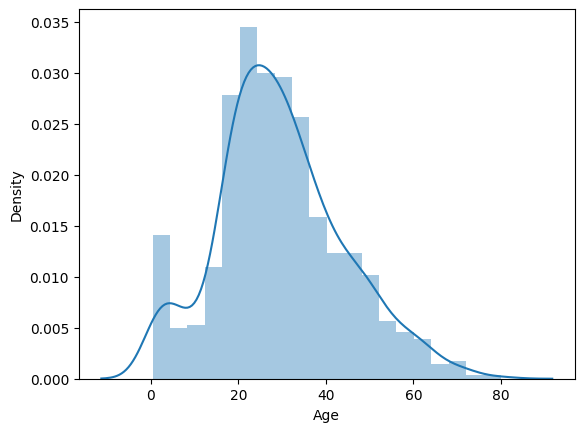

In [17]:
sns.distplot(train["Age"])

In [18]:
train_age = np.random.randint(train["Age"].mean() - train["Age"].std(), train["Age"].mean() + train["Age"].std(), 177 )

In [19]:
test_age = np.random.randint(test["Age"].mean() - test["Age"].std(), test["Age"].mean() + test["Age"].std(), 86 )

In [20]:
train.loc[train["Age"].isnull(), "Age"] = train_age

In [21]:
test.loc[test["Age"].isnull(), "Age"] = test_age

In [22]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [23]:
# EDA
train.groupby(["Pclass"])["Survived"].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [24]:
train.groupby(["Sex"])["Survived"].mean() * 100


Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [25]:
train.groupby(["Embarked"])["Survived"].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

C:\Users\Yash\AppData\Local\Temp\ipykernel_16704\2772394355.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train["Age"])


<Axes: xlabel='Age', ylabel='Density'>

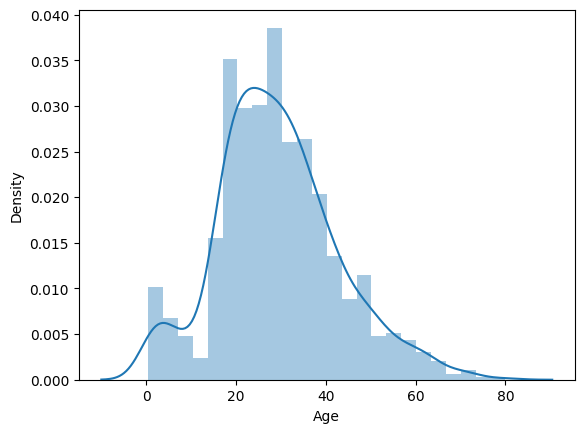

In [26]:
sns.distplot(train["Age"])

In [27]:
train.drop(columns=["Ticket"],inplace=True)
test.drop(columns=["Ticket"],inplace=True)

In [28]:
train["family"] = train["SibSp"] + train["Parch"] + 1

In [29]:
test["family"] =test["SibSp"] +test["Parch"] + 1

In [30]:
train["family"].value_counts()

family
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [31]:
train.groupby(["family"])["Survived"].mean() * 100

family
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

In [32]:
def cal(number):
    if number == 1 : 
        return "Alone"
    if number >1 and number < 5:
        return "Medium"
    else :
        return "Large"

In [34]:
train["family_size"] = train["family"].apply(cal)

In [36]:
test["family_size"] = test["family"].apply(cal)

In [35]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,family,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,2,Medium
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,2,Medium
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,1,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,2,Medium
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1,Alone


In [37]:
train.drop(columns=["SibSp", "Parch", "family"], inplace=True)
test.drop(columns=["SibSp", "Parch", "family"], inplace=True)

In [38]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,S,Medium
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C,Medium
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,S,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,Medium
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,S,Alone


In [39]:
passengerId = test["PassengerId"].values

In [41]:
train.drop(columns=["PassengerId", "Name"], inplace=True)
test.drop(columns=["PassengerId", "Name"], inplace=True)

In [42]:
train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,family_size
0,0,3,male,22.0,7.2500,S,Medium
1,1,1,female,38.0,71.2833,C,Medium
2,1,3,female,26.0,7.9250,S,Alone
3,1,1,female,35.0,53.1000,S,Medium
4,0,3,male,35.0,8.0500,S,Alone
